# Fase 4 (parte A) — Modelos de Machine Learning clásico
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
Dos modelos clásicos (Random Forest, XGBoost) sobre características HOG + color HSV
(1860 dims), con **GridSearchCV (k=5)** optimizando F1-macro.

**Ablation:** entrenamos cada modelo con dos variantes de TRAIN —**con** y **sin**
los recortes de Mixed (`mixed_seg`)— manteniendo idénticos val/test, para medir si
ese enriquecimiento (de etiqueta ruidosa) ayuda o estorba. Guardamos la variante
ganadora.

In [1]:
import sys, pathlib, time
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, joblib
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
from src.config import QUALITY_CLASSES, MODELS_DIR, FIGURES_DIR, SEED
from src.data.preprocessing import load_manifest
from src.features.extract import build_feature_matrix

## 1. Características: train (completo), train (sin mixed_seg), val, test

In [2]:
m_train = load_manifest('train')
m_train_nomix = m_train[m_train['source'] != 'mixed_seg'].copy()
Xtr,  ytr  = build_feature_matrix(m_train,       'train')
Xtrn, ytrn = build_feature_matrix(m_train_nomix, 'train_nomixed')
Xva,  yva  = build_feature_matrix(load_manifest('val'),  'val')
Xte,  yte  = build_feature_matrix(load_manifest('test'), 'test')
print(f"train completo={Xtr.shape[0]} | train sin mixed_seg={Xtrn.shape[0]} | val={Xva.shape[0]} | test={Xte.shape[0]}")

train completo=6591 | train sin mixed_seg=5066 | val=1058 | test=1076


## 2. Línea base

In [3]:
dummy = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)
base_acc=accuracy_score(yte,dummy.predict(Xte)); base_f1=f1_score(yte,dummy.predict(Xte),average='macro')
print(f"Baseline -> accuracy={base_acc:.3f} | f1_macro={base_f1:.3f}")

Baseline -> accuracy=0.328 | f1_macro=0.165


## 3. Búsqueda de hiperparámetros (GridSearchCV, k=5)
Hacemos la búsqueda sobre el train **completo**; el ablation reutiliza esos mismos
hiperparámetros en ambas variantes (aísla el efecto de los datos, no del tuning).

In [4]:
rf_grid = {'n_estimators':[200,400], 'max_depth':[None,20], 'min_samples_split':[2,5]}
t=time.time()
rf_gs = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=SEED, n_jobs=1),
                     rf_grid, cv=5, scoring='f1_macro', n_jobs=-1).fit(Xtr, ytr)
print(f"[RF {time.time()-t:.0f}s] {rf_gs.best_params_}")
xgb_grid = {'learning_rate':[0.1,0.3], 'max_depth':[4,6], 'n_estimators':[200,400]}
t=time.time()
xg_gs = GridSearchCV(xgb.XGBClassifier(tree_method='hist', random_state=SEED, n_jobs=1, eval_metric='mlogloss'),
                     xgb_grid, cv=5, scoring='f1_macro', n_jobs=-1).fit(Xtr, ytr)
print(f"[XGB {time.time()-t:.0f}s] {xg_gs.best_params_}")

[RF 451s] {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 400}


/home/juan-pablo/anaconda3/envs/fruit-quality/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[XGB 2267s] {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 400}


## 4. Ablation: con vs sin `mixed_seg`

In [5]:
def fit_eval(base_est, Xt, yt, Xe, ye):
    mdl = clone(base_est).fit(Xt, yt)
    p = mdl.predict(Xe)
    return mdl, accuracy_score(ye,p), f1_score(ye,p,average='macro')

rf_base = RandomForestClassifier(class_weight='balanced', random_state=SEED,
                                 n_jobs=-1, **rf_gs.best_params_)
xg_base = xgb.XGBClassifier(tree_method='hist', random_state=SEED, n_jobs=-1,
                            eval_metric='mlogloss', **xg_gs.best_params_)
variants = {'con mixed_seg':(Xtr,ytr), 'sin mixed_seg':(Xtrn,ytrn)}
models={}; rows=[]
for vname,(Xt,yt) in variants.items():
    for mname, base in [('Random Forest',rf_base),('XGBoost',xg_base)]:
        mdl,acc,f1 = fit_eval(base, Xt, yt, Xte, yte)
        models[(mname,vname)]=mdl
        rows.append({'modelo':mname,'variante':vname,'accuracy':acc,'f1_macro':f1})
abl = pd.DataFrame(rows)
print(abl.pivot(index='modelo', columns='variante', values='f1_macro').round(4).to_string())
print("\n(valores = F1-macro en test)")
display(abl.round(4))

variante       con mixed_seg  sin mixed_seg
modelo                                     
Random Forest         0.8483         0.8861
XGBoost               0.8909         0.9053

(valores = F1-macro en test)


,modelo,variante,accuracy,f1_macro
0,Random Forest,con mixed_seg,0.8485,0.8483
1,XGBoost,con mixed_seg,0.8913,0.8909
2,Random Forest,sin mixed_seg,0.8857,0.8861
3,XGBoost,sin mixed_seg,0.9052,0.9053


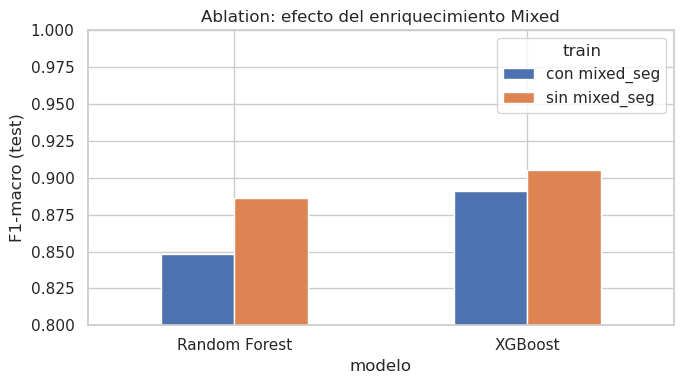

Random Forest: mejor variante = 'sin mixed_seg' (f1=0.8861)
XGBoost: mejor variante = 'sin mixed_seg' (f1=0.9053)


In [6]:
# Elegir la mejor variante por modelo (F1-macro test) y graficar el ablation
fig,ax=plt.subplots(figsize=(7,4))
abl.pivot(index='modelo',columns='variante',values='f1_macro').plot.bar(ax=ax, rot=0)
ax.set_ylim(0.8,1.0); ax.set_ylabel('F1-macro (test)'); ax.set_title('Ablation: efecto del enriquecimiento Mixed')
ax.legend(title='train'); plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase4_ablation_ml.pdf", bbox_inches="tight"); plt.show()

best={}
for mname in ['Random Forest','XGBoost']:
    sub=abl[abl.modelo==mname].sort_values('f1_macro',ascending=False).iloc[0]
    best[mname]=sub['variante']
    print(f"{mname}: mejor variante = '{sub['variante']}' (f1={sub['f1_macro']:.4f})")

## 5. Evaluación detallada de los modelos ganadores

In [7]:
results=[{'modelo':'Baseline','accuracy':base_acc,'f1_macro':base_f1}]
chosen={}
for mname in ['Random Forest','XGBoost']:
    mdl=models[(mname,best[mname])]; chosen[mname]=mdl
    p=mdl.predict(Xte); acc=accuracy_score(yte,p); f1=f1_score(yte,p,average='macro')
    results.append({'modelo':f"{mname} ({best[mname]})",'accuracy':acc,'f1_macro':f1})
    print(f"=== {mname} ({best[mname]}) ===")
    print(classification_report(yte,p,target_names=QUALITY_CLASSES,digits=3))
res=pd.DataFrame(results).set_index('modelo'); print(res.round(3).to_string())

=== Random Forest (sin mixed_seg) ===
              precision    recall  f1-score   support

     Premium      0.870     0.863     0.867       365
    Estándar      0.860     0.891     0.875       358
    Descarte      0.930     0.904     0.917       353

    accuracy                          0.886      1076
   macro avg      0.887     0.886     0.886      1076
weighted avg      0.886     0.886     0.886      1076

=== XGBoost (sin mixed_seg) ===


              precision    recall  f1-score   support

     Premium      0.903     0.866     0.884       365
    Estándar      0.886     0.916     0.901       358
    Descarte      0.927     0.935     0.931       353

    accuracy                          0.905      1076
   macro avg      0.905     0.906     0.905      1076
weighted avg      0.905     0.905     0.905      1076

                               accuracy  f1_macro
modelo                                           
Baseline                          0.328     0.165
Random Forest (sin mixed_seg)     0.886     0.886
XGBoost (sin mixed_seg)           0.905     0.905


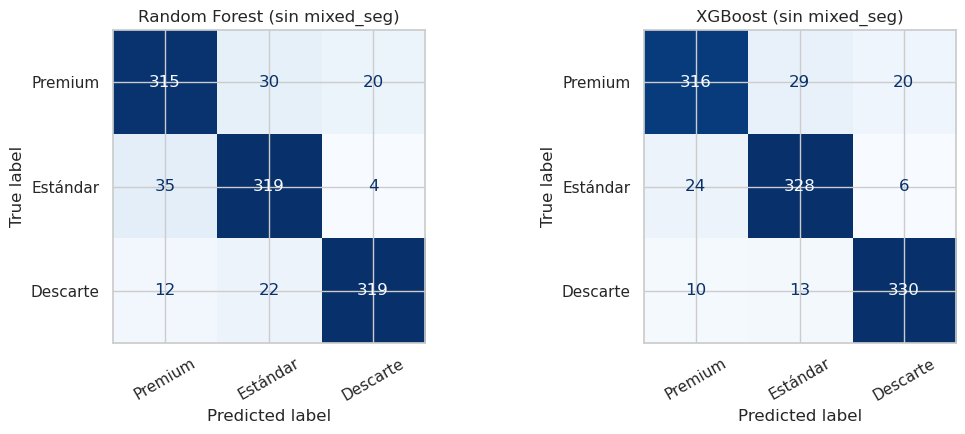

In [8]:
fig,ax=plt.subplots(1,2,figsize=(11,4.5))
for a,mname in zip(ax,['Random Forest','XGBoost']):
    p=chosen[mname].predict(Xte)
    ConfusionMatrixDisplay(confusion_matrix(yte,p),display_labels=QUALITY_CLASSES).plot(ax=a,cmap='Blues',colorbar=False)
    a.set_title(f"{mname} ({best[mname]})"); a.tick_params(axis='x',rotation=30)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase4_ml_confusion.pdf", bbox_inches="tight"); plt.show()

## 6. Importancia por familia de características (RF ganador)

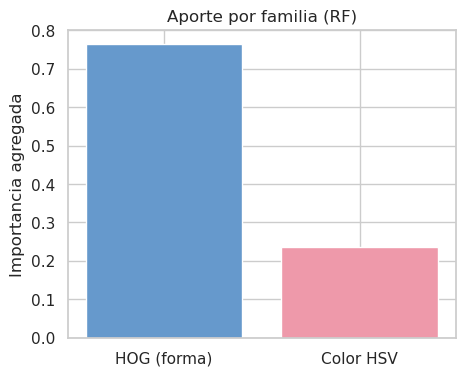

HOG=0.76 | Color=0.24


In [9]:
imp=chosen['Random Forest'].feature_importances_; n_hog=1764
plt.figure(figsize=(5,4))
plt.bar(['HOG (forma)','Color HSV'],[imp[:n_hog].sum(),imp[n_hog:].sum()],color=['#69c','#e9a'])
plt.ylabel('Importancia agregada'); plt.title('Aporte por familia (RF)')
plt.savefig(FIGURES_DIR/"fase4_ml_importancia.pdf", bbox_inches="tight"); plt.show()
print(f"HOG={imp[:n_hog].sum():.2f} | Color={imp[n_hog:].sum():.2f}")

## 7. Guardado de los mejores modelos

In [10]:
joblib.dump(chosen['Random Forest'], MODELS_DIR/"random_forest.pkl")
joblib.dump(chosen['XGBoost'],       MODELS_DIR/"xgboost.pkl")
best_overall = max(['Random Forest','XGBoost'], key=lambda m: res.loc[f"{m} ({best[m]})",'f1_macro'])
joblib.dump(chosen[best_overall], MODELS_DIR/"best_quality_ml.pkl")
abl.to_csv(MODELS_DIR/"ablation_ml.csv", index=False)
print(f"Mejor ML: {best_overall} ({best[best_overall]}) -> best_quality_ml.pkl")
print("Ablation guardado en models/saved/ablation_ml.csv")

Mejor ML: XGBoost (sin mixed_seg) -> best_quality_ml.pkl
Ablation guardado en models/saved/ablation_ml.csv


## Resumen
- **GridSearchCV (k=5)** para RF y XGBoost.
- **Ablation con/sin `mixed_seg`** (mismos val/test): se conserva la variante ganadora por modelo.
- Ambos superan ampliamente la línea base; el mejor se guarda para el despliegue.